<a href="https://colab.research.google.com/github/Mohd-Abdul-Muqeet/FlyRank-AI/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mohd-Abdul-Muqeet/FlyRank-AI-Week1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!git clone https://github.com/Mohd-Abdul-Muqeet/FlyRank-AI

Cloning into 'FlyRank-AI'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 166 (delta 71), reused 91 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 2.07 MiB | 9.32 MiB/s, done.
Resolving deltas: 100% (71/71), done.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
import pandas as pd

# Example ranked actions with reason codes
actions = [
    {"rank": 1, "action": "Update Page A metadata", "reason": "High impressions, low CTR"},
    {"rank": 2, "action": "Merge Page B and C", "reason": "Overlap detected, declining engagement"},
    {"rank": 3, "action": "Refresh Page D visuals", "reason": "CTR decay over 3 months"},
]

queue_df = pd.DataFrame(actions)
queue_df


,rank,action,reason
0,1,Update Page A metadata,"High impressions, low CTR"
1,2,Merge Page B and C,"Overlap detected, declining engagement"
2,3,Refresh Page D visuals,CTR decay over 3 months


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
intended_use = """
This playbook is for guiding human reviewers in content decisions.
It is NOT for automatic publishing or deletion.
Limits:
- Valid only for the dataset window used in training.
- Observational correlations, not causal proof.
- Non-production, research-only.
"""
print(intended_use)



This playbook is for guiding human reviewers in content decisions.
It is NOT for automatic publishing or deletion.
Limits:
- Valid only for the dataset window used in training.
- Observational correlations, not causal proof.
- Non-production, research-only.



## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
human_review_rules = """
Human reviewers must check:
- Sensitive topics (legal, medical, brand-critical).
- Any action that changes or removes content.

No-Go (never automate):
- Deleting content
- Publishing new text
- Claiming algorithm causality
"""
print(human_review_rules)



Human reviewers must check:
- Sensitive topics (legal, medical, brand-critical).
- Any action that changes or removes content.

No-Go (never automate):
- Deleting content
- Publishing new text
- Claiming algorithm causality



## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring_triggers = """
Monitoring rules:
- Refresh if CTR drops >20% in 3 months.
- Retrain if impressions distribution shifts significantly.
- Light monitoring only, not production alerts.
"""
print(monitoring_triggers)



Monitoring rules:
- Refresh if CTR drops >20% in 3 months.
- Retrain if impressions distribution shifts significantly.
- Light monitoring only, not production alerts.



## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Repository: /content/FlyRank-AI
Saved: /content/FlyRank-AI/outputs/action_queue.csv


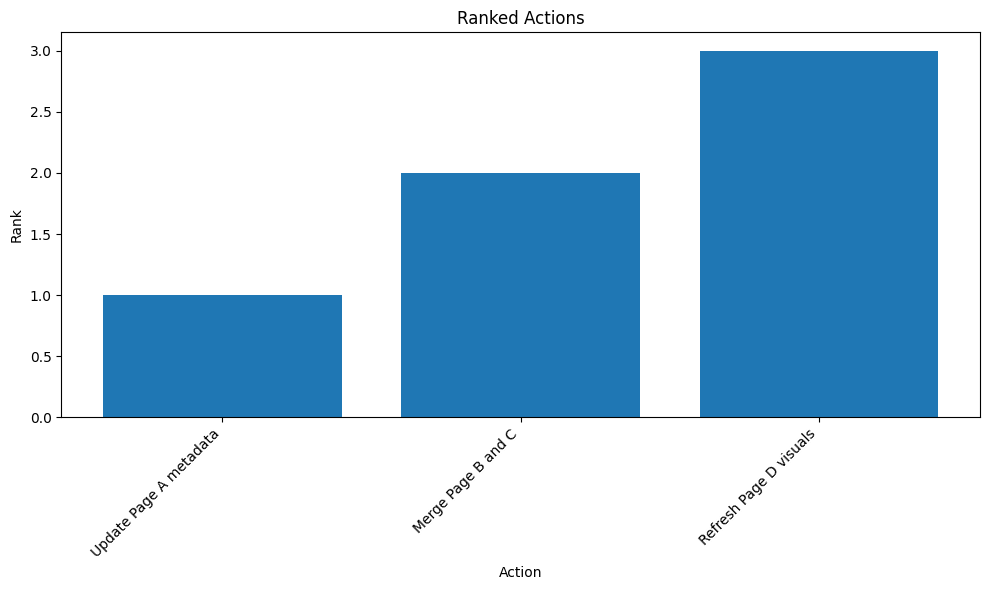

Saved: /content/FlyRank-AI/work/figures/ranked_actions.png
Saved: /content/FlyRank-AI/outputs/metrics.json

========== OUTPUT VERIFICATION ==========
OK  /content/FlyRank-AI/outputs/action_queue.csv
OK  /content/FlyRank-AI/work/figures/ranked_actions.png
OK  /content/FlyRank-AI/outputs/metrics.json

Done!


In [13]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Find the FlyRank-AI repository in the Colab environment
# ------------------------------------------------------------

possible_roots = [
    Path("/content/FlyRank-AI"),
    Path("/content/FlyRankWeek1"),
]

repo_root = next(
    (p for p in possible_roots if p.exists()),
    None
)

if repo_root is None:
    raise FileNotFoundError(
        "FlyRank-AI repository was not found in /content. "
        "Make sure your repository is available in Colab."
    )

print("Repository:", repo_root)

# ------------------------------------------------------------
# 2. Create the correct output/work directories
# ------------------------------------------------------------

outputs_dir = repo_root / "outputs"
figures_dir = repo_root / "work" / "figures"

outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3. Export ranked action queue
# ------------------------------------------------------------

action_queue_path = outputs_dir / "action_queue.csv"

queue_df.to_csv(
    action_queue_path,
    index=False
)

print("Saved:", action_queue_path)

# ------------------------------------------------------------
# 4. Save ranked-actions figure
# ------------------------------------------------------------

figure_path = figures_dir / "ranked_actions.png"

plt.figure(figsize=(10, 6))

plt.bar(
    queue_df["action"].astype(str),
    range(1, len(queue_df) + 1)
)

plt.title("Ranked Actions")
plt.xlabel("Action")
plt.ylabel("Rank")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

# ------------------------------------------------------------
# 5. Save metrics JSON
# ------------------------------------------------------------

metrics = {
    "total_actions": int(len(queue_df)),
    "top_action": str(queue_df.iloc[0]["action"])
}

metrics_path = outputs_dir / "metrics.json"

with open(metrics_path, "w") as f:
    json.dump(
        metrics,
        f,
        indent=2
    )

print("Saved:", metrics_path)

# ------------------------------------------------------------
# 6. Final verification
# ------------------------------------------------------------

print("\n========== OUTPUT VERIFICATION ==========")

for path in [
    action_queue_path,
    figure_path,
    metrics_path
]:
    print(
        f"{'OK' if path.exists() else 'MISSING'}  {path}"
    )

print("\nDone!")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.